<a href="https://colab.research.google.com/github/jjww1024/BIOAI/blob/main/11_%E1%84%89%E1%85%A2%E1%86%BC%E1%84%89%E1%85%A5%E1%86%BC%E1%84%92%E1%85%A7%E1%86%BC%E1%84%87%E1%85%AE%E1%86%AB%E1%84%8C%E1%85%A1%E1%84%89%E1%85%A5%E1%86%AF%E1%84%80%E1%85%A8_MolGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실습 11 · 생성형 파운데이션 모델 — 신약 후보 분자 만들기 (De novo Design)
### AI 가 '읽는' 것을 넘어 '새로 그려내는' 단계


앞에서는 이미 존재하는 분자를 **분석·예측**했습니다. 이번에는 반대로,
AI 가 세상에 없던 **새로운 분자를 스스로 설계(생성)** 합니다.
GPT 가 문장을 이어 쓰듯, **SMILES 를 학습한 생성모델**은 화학적으로 그럴듯한
새 분자를 한 글자씩 이어서 만들어냅니다. 이것이 신약개발의 후보물질 탐색
비용을 획기적으로 줄이는 **생성형 AI 신약설계**입니다.

**이 노트북에서 배우는 것**
1. 수백만 개 분자로 사전학습된 **생성모델**을 불러와 새 분자 **샘플링**
2. 만들어진 분자가 **화학적으로 유효한지** RDKit 으로 검증
3. **약물 유사성(Lipinski, QED)** 으로 좋은 후보만 걸러내는 **생성→필터 깔때기**
4. 특정 성질을 노리는 **조건부 생성(guided generation)** 개념

> 💡 런타임을 **T4 GPU** 로 바꾸면 훨씬 빠릅니다. (CPU 로도 동작합니다)


In [1]:
!pip install transformers torch rdkit sentencepiece tiktoken -q
import torch, numpy as np, pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, QED, Crippen
from rdkit import RDLogger; RDLogger.DisableLog("rdApp.*")   # 경고 숨김
device = "cuda" if torch.cuda.is_available() else "cpu"
print("준비 완료 ✅  (device:", device, ")")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 34.5 MB/s eta 0:00:00
준비 완료 ✅  (device: cuda )


## 1. ⭐ 분자 생성모델 불러오기 (SMILES 를 학습한 GPT)
`entropy/gpt2_zinc_87m` 은 **ZINC 데이터베이스의 수백만 분자**로 사전학습된
GPT-2 계열 생성모델입니다. 아무 입력 없이 실행하면, 모델이 학습한
'화학 언어' 로 **새로운 SMILES 를 처음부터 써 내려갑니다.**


In [2]:
from transformers import GPT2LMHeadModel, AutoTokenizer

model_name = "entropy/gpt2_zinc_87m"
tok = AutoTokenizer.from_pretrained(model_name)
gen_model = GPT2LMHeadModel.from_pretrained(model_name).to(device).eval()
print("생성모델 로드 완료 ✅  (파라미터 약 87M, ZINC 사전학습)")

config.json:   0%|          | 0.00/788 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/40.5k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/24.4k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/435 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  350MB            

...

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: entropy/gpt2_zinc_87m
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B /  350MB            

model.safetensors: downloading bytes:           |  0.00B            

생성모델 로드 완료 ✅  (파라미터 약 87M, ZINC 사전학습)


## 2. 새로운 분자 100개 샘플링하기
`do_sample=True` 는 매번 다른 결과를 뽑는 **창의적 생성** 모드입니다.
`temperature` 가 높을수록 더 과감(다양)하게, `top_k` 는 후보 글자 수를 제한합니다.


In [3]:
N = 100
torch.manual_seed(42)
# bos 토큰에서 시작해 분자를 자유 생성
bos = torch.tensor([[tok.bos_token_id]] * N).to(device)
with torch.no_grad():
    out = gen_model.generate(
        bos, do_sample=True, max_length=64,
        temperature=1.0, top_k=30,
        pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
raw_smiles = tok.batch_decode(out, skip_special_tokens=True)
raw_smiles = [s.strip() for s in raw_smiles]
print("생성된 SMILES 예시 5개:")
for s in raw_smiles[:5]:
    print("  ", s)
# SMILES 표기법에서 @ 기호는 카이랄성 또는 입체화학을 나타냅니다. 이는 카이랄 중심 주위의 원자들의 3D 배열에 대해 알려줍니다.
# @: 해당 원자가 특정 방향(원자에서 다음 암시적으로 정의된 원자로 향하는 결합을 따라 볼 때 반시계 방향으로 치환기 배열)을 가진 카이랄 중심임을 지정합니다.
# @@: 카이랄 중심에서 반대쪽 카이랄성(시계 방향 배열)을 지정합니다.
# 이러한 기호는 분자의 3D 구조를 정확하게 표현하는 데 중요하며, 이는 분자의 화학적 및 생물학적 특성에 상당한 영향을 미칠 수 있습니다.


생성된 SMILES 예시 5개:
   C[C@H](NC[C@H]1CCC2(CCC2)O1)c1cccc(NS(C)(=O)=O)c1
   O=C(O)c1cccc(S(=O)(=O)N2CCC[C@@](CO)(Cc3ccccc3)C2)c1F
   CC/C(C)=C/C(=O)N1CCCC[C@@H]1CNC(=O)[C@@H]1CCO[C@H]1CC
   CN(C)CCOc1ccc(N(C)C(=O)CCc2nnc(-c3ccccc3)o2)cc1
   CN1CCC(C(=O)N2CC[C@H](CNC[C@@H]3CCNC(=O)CC3)C2)CC1


## 3. 유효성 검증 — AI 가 만든 게 '진짜 분자' 일까?
생성모델은 가끔 문법이 틀린(=화학적으로 불가능한) SMILES 도 만듭니다.
RDKit 으로 **파싱이 되는 것만** 유효한 분자로 인정합니다.
유효율(validity)은 생성모델의 품질 지표입니다.


In [4]:
valid = []
for s in raw_smiles:
    m = Chem.MolFromSmiles(s)
    if m is not None:
        valid.append(Chem.MolToSmiles(m))   # 표준화(canonical)
valid = list(dict.fromkeys(valid))          # 중복 제거
print(f"생성 {len(raw_smiles)}개 중 유효 & 고유 분자: {len(valid)}개")
print(f"유효율(validity): {len(valid)/len(raw_smiles)*100:.0f}%")

# 학습 데이터에 없던 '새로운' 분자인지도 확인 가능(여기선 개념만)
print("→ 이 분자들은 대부분 데이터베이스에 없던 새 구조입니다 (de novo)")


생성 100개 중 유효 & 고유 분자: 100개
유효율(validity): 100%
→ 이 분자들은 대부분 데이터베이스에 없던 새 구조입니다 (de novo)


## 4. 약물 유사성 필터 — 좋은 후보만 남기기 (생성→필터 깔때기)
분자를 많이 만드는 것보다 **쓸 만한 것을 고르는 것**이 중요합니다.
예제 12(가상 스크리닝)처럼, 약물다움 규칙으로 깔때기를 통과시킵니다.
- **Lipinski Rule of 5**: 경구 약물이 되기 좋은 조건
- **QED**: 0~1 사이 '약물다움' 종합 점수 (높을수록 좋음)


In [5]:
def profile(smi):
    m = Chem.MolFromSmiles(smi)
    mw   = Descriptors.MolWt(m)
    logp = Crippen.MolLogP(m)
    hbd  = Descriptors.NumHDonors(m)
    hba  = Descriptors.NumHAcceptors(m)
    qed  = QED.qed(m)
    lipinski = (mw <= 500) and (logp <= 5) and (hbd <= 5) and (hba <= 10)
    return dict(SMILES=smi, MW=round(mw,1), logP=round(logp,2),
                HBD=hbd, HBA=hba, QED=round(qed,3), Lipinski=lipinski)
    # QED는 1에 가까울수록 약이 될 수 있는 가능성이 높은 것

df = pd.DataFrame([profile(s) for s in valid])
# 깔때기: Lipinski 통과 + QED 상위
hits = df[df["Lipinski"]].sort_values("QED", ascending=False).reset_index(drop=True)
print(f"Lipinski 통과: {df['Lipinski'].sum()} / {len(df)}")
print("QED 기준 상위 후보 5개:")
hits.head(5)


Lipinski 통과: 93 / 100
QED 기준 상위 후보 5개:


,SMILES,MW,logP,HBD,HBA,QED,Lipinski
0,CCn1ccc(CNC(=O)N(C)Cc2c(F)cccc2Cl)n1,324.8,3.04,1,2,0.919,True
1,CC(C)c1nccc(NC[C@@H]2CN(C(=O)c3ccn(C)c3)C[C@H]...,341.5,2.76,1,4,0.908,True
2,C[C@@H]1[C@@H](NC(=O)Cn2cccn2)CCN1C(=O)c1ccncc1,313.4,0.70,1,4,0.901,True
3,Cc1cn(C)nc1C(=O)N[C@H]1CCCN(C(=O)c2cc[nH]c2)C1,315.4,1.09,2,3,0.889,True
4,C[C@H]1SCCN(CC(=O)NC(=O)NC(C)(C)C)[C@@H]1c1ccccc1,349.5,2.79,2,4,0.881,True


## 5. 상위 후보 분자 그려보기
AI 가 설계한 신약 후보들을 눈으로 확인합니다.


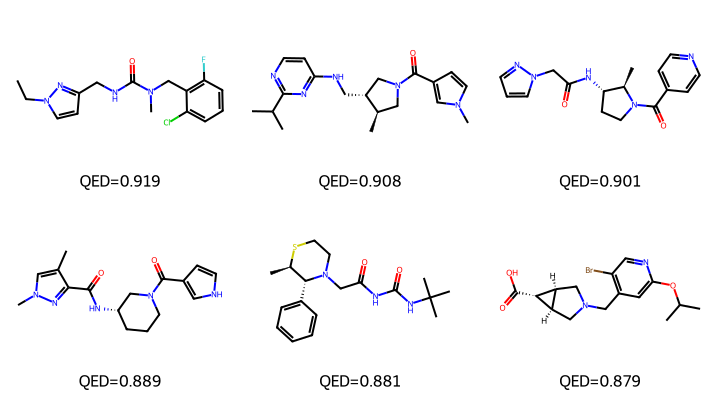

In [6]:
top = hits.head(6)
mols = [Chem.MolFromSmiles(s) for s in top["SMILES"]]
legends = [f"QED={q}" for q in top["QED"]]
Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(240,200), legends=legends)


## 6. (심화) 조건부 생성 개념 — '원하는 성질' 을 노리기
현업에서는 그냥 아무거나 만들지 않고 **목표 성질을 향해** 생성을 유도합니다.
간단한 버전으로, 많이 생성한 뒤 **원하는 조건으로 필터**하면 조건부 생성과
비슷한 효과를 냅니다. (진짜 조건부 생성은 REINVENT·강화학습·조건토큰을 사용)


In [7]:
# 예: '작고(MW<350) 지용성 적당한(1<logP<3)' 후보만 원한다면
target = df[(df.MW < 350) & (df.logP.between(1,3)) & (df.Lipinski)]
target = target.sort_values("QED", ascending=False)
print(f"목표 조건을 만족하는 후보: {len(target)}개")
target.head(5)


목표 조건을 만족하는 후보: 36개


,SMILES,MW,logP,HBD,HBA,QED,Lipinski
71,CC(C)c1nccc(NC[C@@H]2CN(C(=O)c3ccn(C)c3)C[C@H]...,341.5,2.76,1,4,0.908,True
39,Cc1cn(C)nc1C(=O)N[C@H]1CCCN(C(=O)c2cc[nH]c2)C1,315.4,1.09,2,3,0.889,True
63,C[C@H]1SCCN(CC(=O)NC(=O)NC(C)(C)C)[C@@H]1c1ccccc1,349.5,2.79,2,4,0.881,True
47,CC(C)CN(C)C(=O)Nc1ccnn1C(C)C,238.3,2.58,1,2,0.876,True
66,Cn1ncc(CNCc2cc(C#N)ccc2F)n1,245.3,1.12,1,4,0.876,True


## 7. 생성형 신약설계 지형도 (참고)
| 방식 | 대표 도구 | 특징 |
|---|---|---|
| **언어모델 생성** | GPT/ZINC, ChemGPT, MolGPT | SMILES/SELFIES 를 이어 씀 (이 예제) |
| **강화학습 최적화** | REINVENT | 목표 점수(활성·ADMET)로 생성 유도 |
| **확산모델** | 3D 분자·결합구조 생성 | 단백질 포켓에 맞춰 설계 |
| **VAE/GraphGen** | JT-VAE, GraphAF | 잠재공간 탐색으로 신규 구조 |

**표준 워크플로우**: 대량 생성 → 유효성 검증 → ADMET·약물다움 필터 →
도킹·활성예측으로 검증 → 유망 후보 합성/실험


## 정리 & 현장 응용
- **생성형 AI 신약설계**: 분자를 '분석' 하는 것을 넘어 '새로 만든다'
- **생성 → 검증 → 필터 깔때기**: 많이 만들고, 유효성·약물다움으로 좁힌다
- 이후 예제 11(활성)·12(스크리닝)·14(도킹)과 연결하면 **후보발굴 파이프라인 완성**
- 확장: REINVENT 로 목표 성질 최적화, 확산모델로 단백질 포켓 맞춤 설계
- **면접 한 문장**: "SMILES 를 학습한 생성모델로 신규 후보를 대량 설계하고,
  RDKit 유효성·약물다움 필터와 도킹으로 좁히는 생성형 신약설계 파이프라인을
  경험했습니다."
